In [1]:
import torch

In [2]:
def rotation_mat(a):
  diag=a
  off_diag=(1-a**2)**(1/2)*1j
  W=[[diag,off_diag],[off_diag,diag]]
  return W
def generate_many_sro(a_vals):
  w_array=[]
  for a in a_vals:
    w=rotation_mat(a)
    w_array.append(w)

  return torch.tensor(w_array,dtype=torch.complex64,requires_grad=False)



In [3]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 73.3 MB/s eta 0:00:00


In [4]:
import pennylane as qp
def QSP_circ(phi,W):
  qp.Hadamard(wires=0)
  for angle in phi[:-1]:
    qp.RZ(angle,wires=0)
    qp.QubitUnitary(W,wires=0)

  qp.RZ(phi[-1],wires=0)
  qp.Hadamard(wires=0)
  return

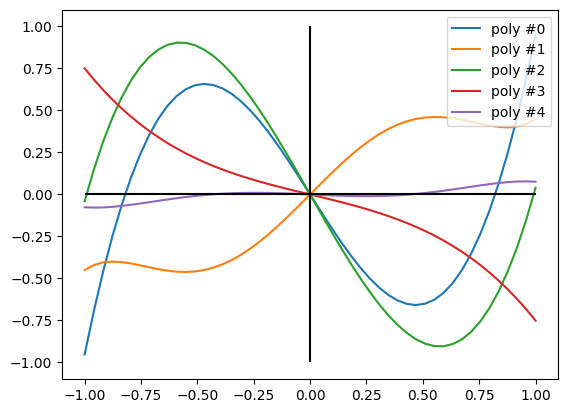

In [5]:
import math
import matplotlib.pyplot as plt

d = 5
a_vals = torch.linspace(-1, 1, 50)
w_mats = generate_many_sro(a_vals)

gen = torch.Generator()
gen.manual_seed(444422)

for i in range(5):
    phi = torch.rand(d + 1, generator=gen) * 2 * torch.tensor([math.pi], requires_grad=False)
    matrix_func = qp.matrix(QSP_circ, wire_order=[0])
    y_vals = [matrix_func(phi, w)[0, 0].real for w in w_mats]

    plt.plot(a_vals, y_vals, label=f"poly #{i}")

plt.vlines(0.0, -1.0, 1.0, color="black")
plt.hlines(0.0, -1.0, 1.0, color="black")
plt.legend(loc=1)
plt.show()

In [6]:
torch_pi=torch.Tensor([math.pi])
class QSP_func_fit(torch.nn.Module):
  def __init__(self,degree,num_vals,random_seed=None):
    super().__init__()
    if random_seed is None:
      self.phi=torch_pi*torch.rand(degree+1,requires_grad=True)
    else:
      gen=torch.Generator()
      gen.manual_seed(random_seed)
      self.phi=torch_pi*torch.rand(degree+1,requires_grad=True,generator=gen)
    self.phi=torch.nn.Parameter(self.phi)
    self.num_phi=degree+1
    self.num_vals=num_vals
  def forward(self,omega_mats):
    y_pred=[]
    generate_qsp_mat=qp.matrix(QSP_circ,wire_order=[0])

    for w in omega_mats:
      u_qsp=generate_qsp_mat(self.phi,w)
      P_a=u_qsp[0,0]
      y_pred.append(P_a.real)

    return torch.stack(y_pred,0)


In [7]:
class Model_runner:
  def __init__(self,model,degree,num_samples,x_vals,process_x_vals,y_true):
    self.model=model
    self.degree=degree
    self.num_samples=num_samples
    self.x_vals=x_vals
    self.inp=process_x_vals(x_vals)
    self.y_true=y_true

  def execute(self,random_seed=13_02_1967,max_shots=2500,verbose=True):
    model=self.model(degree=self.degree,num_vals=self.num_samples,random_seed=random_seed)
    criterion=torch.nn.MSELoss(reduction="sum")
    optimizer=torch.optim.SGD(model.parameters(),lr=1e-5)
    t=0
    loss_val=1.0
    while(t<=max_shots) and (loss_val>0.5):
      self.y_pred=model(self.inp)
      if t==1:
        self.init_y_pred=self.y_pred

      loss=criterion(self.y_pred,self.y_true)
      loss_val=loss.item()
      if(t%1000==0) and verbose:
        print(loss_val)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      t+=1
    self.model_params=model.phi
  def plot_result(self, show=True):
        """Plot the results"""
        plt.plot(self.x_vals, self.y_true.tolist(), "--b", label="target func")
        plt.plot(self.x_vals, self.y_pred.tolist(), ".g", label="optim params")
        plt.plot(self.x_vals, self.init_y_pred.tolist(), ".r", label="init params")
        plt.legend(loc=1)

        if show:
            plt.show()




/tmp/ipykernel_401/1595985946.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(4*x**5-5* x**3 +x,requires_grad=False)


13.593811988830566
11.88087272644043
10.22903060913086


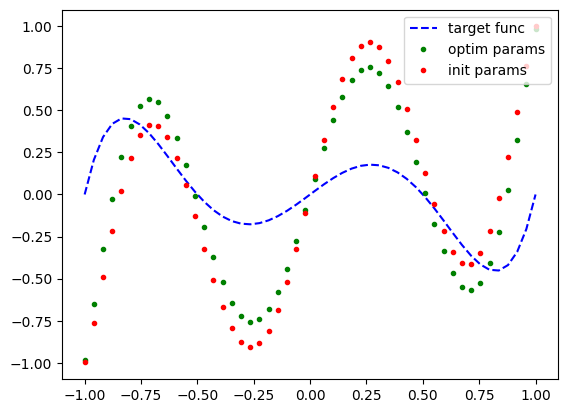

In [10]:
import numpy as np
d=9
num_samples=50
def custom_poly(x):
  return torch.tensor(4*x**5-5* x**3 +x,requires_grad=False)


a_vals=torch.linspace(-1,1,num_samples)
y_true=custom_poly(a_vals)
qsp_model_runner=Model_runner(QSP_func_fit,d,num_samples,a_vals,generate_many_sro,y_true)
qsp_model_runner.execute()
qsp_model_runner.plot_result()